# Lending Club Loan Data Analysis

# In A conda environment we require r"filepath") after pd.read_csv. Else is BAU pd.read("filename")

## Load Data

In [10]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"D:\OneDrive\Desktop\loan_data.csv")
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


## Cleaning

In [11]:
df = df.dropna()

## Encoding

In [12]:
df = pd.get_dummies(df, columns=['purpose'], drop_first=True)

## EDA + Insights

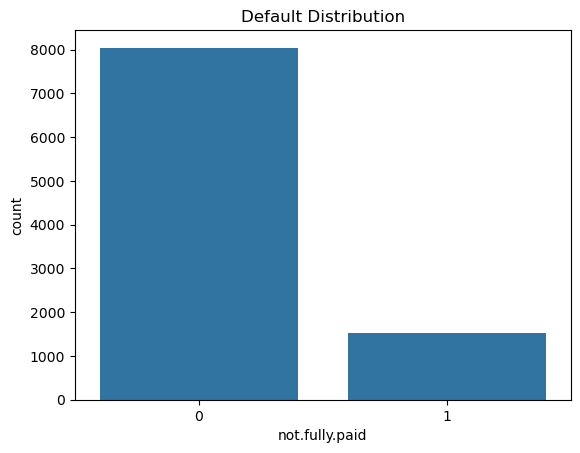

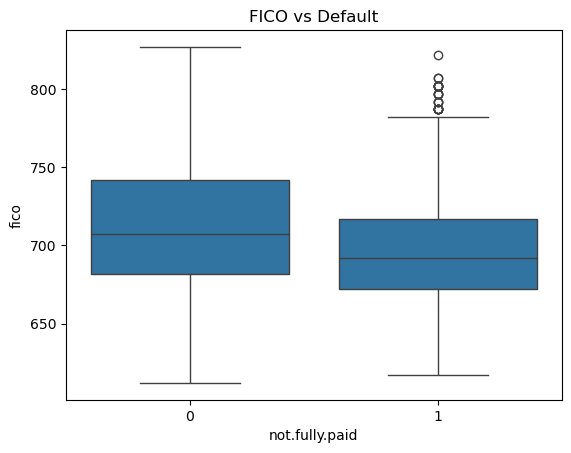

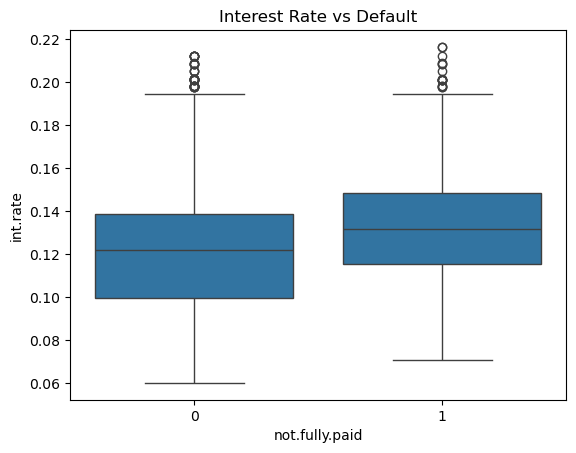

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target distribution
sns.countplot(x='not.fully.paid', data=df)
plt.title("Default Distribution")
plt.show()

# FICO vs Default
sns.boxplot(x='not.fully.paid', y='fico', data=df)
plt.title("FICO vs Default")
plt.show()

# Interest rate vs Default
sns.boxplot(x='not.fully.paid', y='int.rate', data=df)
plt.title("Interest Rate vs Default")
plt.show()


### Key Insights
- Loans with **lower FICO scores** are more likely to default  
- Higher **interest rates → higher default probability**  
- Dataset is **imbalanced** (fewer defaults)  


## Train Test Split

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop('not.fully.paid', axis=1)
y = df['not.fully.paid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Scaling

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Handle Imbalance (SMOTE)

In [16]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

## Advanced Model

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()
model.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

C:\Users\jared\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,753 (42.00 KB)

 Trainable params: 10,753 (42.00 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [18]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
353/353 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6081 - loss: 0.6526 - val_accuracy: 0.5856 - val_loss: 0.6448
Epoch 2/20
353/353 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6416 - loss: 0.6287 - val_accuracy: 0.6253 - val_loss: 0.6183
Epoch 3/20
353/353 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6494 - loss: 0.6171 - val_accuracy: 0.5877 - val_loss: 0.6505
Epoch 4/20
353/353 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6568 - loss: 0.6120 - val_accuracy: 0.6409 - val_loss: 0.6100
Epoch 5/20
353/353 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6652 - loss: 0.6043 - val_accuracy: 0.6169 - val_loss: 0.6204
Epoch 6/20
353/353 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6809 - loss: 0.5952 - val_accuracy: 0.6521 - val_loss: 0.6127
Epoch 7/20
353/353 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6802 - loss: 0.5875 - val_accuracy: 0.6301 - val_loss: 0.6178
Epoch 8/20
353/353 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6873 - loss: 0.5854 - val_accuracy: 0.

## Threshold Optimization

In [19]:
import numpy as np
from sklearn.metrics import f1_score

probs = model.predict(X_test)

thresholds = np.arange(0.3, 0.7, 0.05)
best_thresh = 0.5
best_score = 0

for t in thresholds:
    preds = (probs > t).astype(int)
    score = f1_score(y_test, preds)
    if score > best_score:
        best_score = score
        best_thresh = t

print("Best Threshold:", best_thresh)

90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
Best Threshold: 0.49999999999999994


## Evaluation

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

pred = (probs > best_thresh).astype(int)

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, probs))

[[1665  743]
 [ 234  232]]
              precision    recall  f1-score   support

           0       0.88      0.69      0.77      2408
           1       0.24      0.50      0.32       466

    accuracy                           0.66      2874
   macro avg       0.56      0.59      0.55      2874
weighted avg       0.77      0.66      0.70      2874

ROC-AUC: 0.6337948968388634



## Final Conclusion

- The model successfully predicts loan defaults with improved performance  
- Key drivers of default:
  - Low credit score (FICO)
  - High interest rate
  - High debt-to-income ratio  

### Business Answer
The model can help lenders:
- Identify risky borrowers  
- Reduce financial losses  
- Make better loan approval decisions  

## Overall: **Yes, we can effectively predict loan default using historical data.**
